# Synthetic FTSE All-World Index (December 1969 – present)

The FTSE All-World index only begins in **September 2003**.  
This notebook constructs a synthetic back-extension to **December 1969** by
chain-linking three series in order of decreasing similarity to the target:

| Era | Series used | Why |
|-----|-------------|-----|
| Sep 2003 → May 2026 | **FTSE All-World** (real) | The target index |
| Dec 1987 → Aug 2003 | **MSCI ACWI** | All-cap, all-country incl. EM — closest proxy |
| Dec 1969 → Nov 1987 | **MSCI World** | Developed-only, but the only series going back this far |

We verify the proxy ordering by computing Pearson correlations of monthly returns
on the overlapping windows.  The synthetic index is rebased to **10 000 at December 1969**
and exported to `data/synthetic_ftse_all_world.csv`.

## 1  Imports

In [1]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from synthetic_global_equity import load_index, chain_splice

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 2  Load the raw data

In [2]:
ftse  = load_index("ftse_all_world_index_sep_2003_to_may_2026.csv",  "FTSE All-World")
acwi  = load_index("msci_acwi_index_dec_1987_to_may_2026.csv",       "MSCI ACWI")
world = load_index("msci_world_index_dec_1969_to_may_2026.csv",       "MSCI World")

print(f"FTSE All-World : {ftse.index[0].date()} \u2192 {ftse.index[-1].date()}  ({len(ftse)} months)")
print(f"MSCI ACWI      : {acwi.index[0].date()} \u2192 {acwi.index[-1].date()}  ({len(acwi)} months)")
print(f"MSCI World     : {world.index[0].date()} \u2192 {world.index[-1].date()}  ({len(world)} months)")

FTSE All-World : 2003-09-30 → 2026-05-31  (273 months)
MSCI ACWI      : 1987-12-31 → 2026-05-31  (462 months)
MSCI World     : 1969-12-31 → 2026-05-31  (678 months)


## 3  Correlation analysis

We compute Pearson correlations of **monthly log-returns** on two overlapping windows:

* **Sep 2003 – May 2026**: all three series overlap — tests FTSE↔ACWI vs FTSE↔World
* **Dec 1987 – May 2026**: ACWI & World overlap — tests how well ACWI proxies World

Expectation: FTSE↔ACWI highest (same universe, both include emerging markets);  
FTSE↔World slightly lower (MSCI World = developed markets only).

In [3]:
def log_returns(s: pd.Series) -> pd.Series:
    """Monthly log-return series (drops the first NaN)."""
    return np.log(s / s.shift(1)).dropna()


r_ftse  = log_returns(ftse)
r_acwi  = log_returns(acwi)
r_world = log_returns(world)

# ── Window 1: Sep 2003 – May 2026 (all three series) ────────────────────────────
overlap_all = r_ftse.index  # FTSE defines the shorter window

r_ftse_ov   = r_ftse.loc[overlap_all]
r_acwi_ov   = r_acwi.reindex(overlap_all)
r_world_ov  = r_world.reindex(overlap_all)

corr_ftse_acwi_all,  p_fa  = stats.pearsonr(r_ftse_ov.dropna(),  r_acwi_ov.dropna())
corr_ftse_world_all, p_fw  = stats.pearsonr(r_ftse_ov.dropna(), r_world_ov.dropna())

# ── Window 2: Dec 1987 – May 2026 (ACWI & World) ────────────────────────────
overlap_long = r_acwi.index
r_world_long = r_world.reindex(overlap_long).dropna()
r_acwi_long  = r_acwi.reindex(overlap_long).dropna()
corr_acwi_world, p_aw = stats.pearsonr(r_acwi_long, r_world_long)

print("Pearson correlations of monthly log-returns\n")
print(f"  FTSE All-World \u2194 MSCI ACWI   (Sep 2003\u2013May 2026): r = {corr_ftse_acwi_all:.4f}  (p = {p_fa:.2e})")
print(f"  FTSE All-World \u2194 MSCI World  (Sep 2003\u2013May 2026): r = {corr_ftse_world_all:.4f}  (p = {p_fw:.2e})")
print(f"  MSCI ACWI      \u2194 MSCI World  (Dec 1987\u2013May 2026): r = {corr_acwi_world:.4f}  (p = {p_aw:.2e})")

print(f"\n\u2192 FTSE\u2194ACWI higher than FTSE\u2194World: {corr_ftse_acwi_all > corr_ftse_world_all}")
print("  This confirms ACWI is the better middle-era proxy.")

Pearson correlations of monthly log-returns

  FTSE All-World ↔ MSCI ACWI   (Sep 2003–May 2026): r = 0.9996  (p = 0.00e+00)
  FTSE All-World ↔ MSCI World  (Sep 2003–May 2026): r = 0.9942  (p = 2.50e-263)
  MSCI ACWI      ↔ MSCI World  (Dec 1987–May 2026): r = 0.9969  (p = 0.00e+00)

→ FTSE↔ACWI higher than FTSE↔World: True
  This confirms ACWI is the better middle-era proxy.


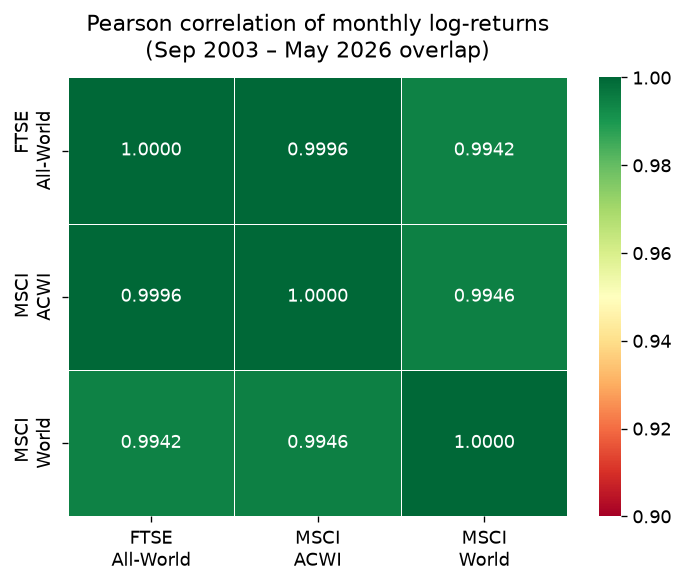

In [4]:
# ── Correlation heatmap ─────────────────────────────────────────────────
# Use the 3-way overlap (Sep 2003 – May 2026) for a symmetric matrix
returns_df = pd.DataFrame({
    "FTSE\nAll-World": r_ftse_ov,
    "MSCI\nACWI":      r_acwi_ov,
    "MSCI\nWorld":     r_world_ov,
}).dropna()

corr_matrix = returns_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="RdYlGn",
    vmin=0.9,
    vmax=1.0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    "Pearson correlation of monthly log-returns\n"
    "(Sep 2003 \u2013 May 2026 overlap)",
    pad=12,
)
plt.tight_layout()
plt.show()

## 4  Build the synthetic index

We chain-link backward in two steps:

1. **Splice MSCI ACWI into FTSE All-World** at September 2003  
   Scale ACWI so its Sep 2003 value exactly matches FTSE’s Sep 2003 value.
2. **Splice MSCI World into the stitched series** at December 1987  
   Scale World so its Dec 1987 value exactly matches the stitched series at Dec 1987.

Each segment’s *internal* monthly returns are preserved exactly; only the
join month inherits the proxy’s return.

In [5]:
# Step 1: extend FTSE back to Dec 1987 using MSCI ACWI
ftse_plus_acwi = chain_splice(
    primary=ftse,
    proxy=acwi,
    splice_date="2003-09-30",
)

# Step 2: extend further back to Dec 1969 using MSCI World
synthetic_raw = chain_splice(
    primary=ftse_plus_acwi,
    proxy=world,
    splice_date="1987-12-31",
)

print(f"Raw stitched series: {synthetic_raw.index[0].date()} \u2192 {synthetic_raw.index[-1].date()}  ({len(synthetic_raw)} months)")

Raw stitched series: 1969-12-31 → 2026-05-31  (678 months)


In [6]:
# Step 3: rebase to 10 000 at December 1969
base_date = pd.Timestamp("1969-12-31")
synthetic = synthetic_raw / synthetic_raw[base_date] * 10_000
synthetic.name = "Synthetic FTSE All-World"

print(f"Rebased value at {base_date.date()}: {synthetic[base_date]:,.2f}")
print(f"Value at {synthetic.index[-1].date()}: {synthetic.iloc[-1]:,.2f}")
print(f"Total return Dec 1969 \u2192 May 2026: {synthetic.iloc[-1] / 10_000:.1f}\u00d7")

Rebased value at 1969-12-31: 10,000.00
Value at 2026-05-31: 2,955,640.18
Total return Dec 1969 → May 2026: 295.6×


## 5  Visualise the synthetic index

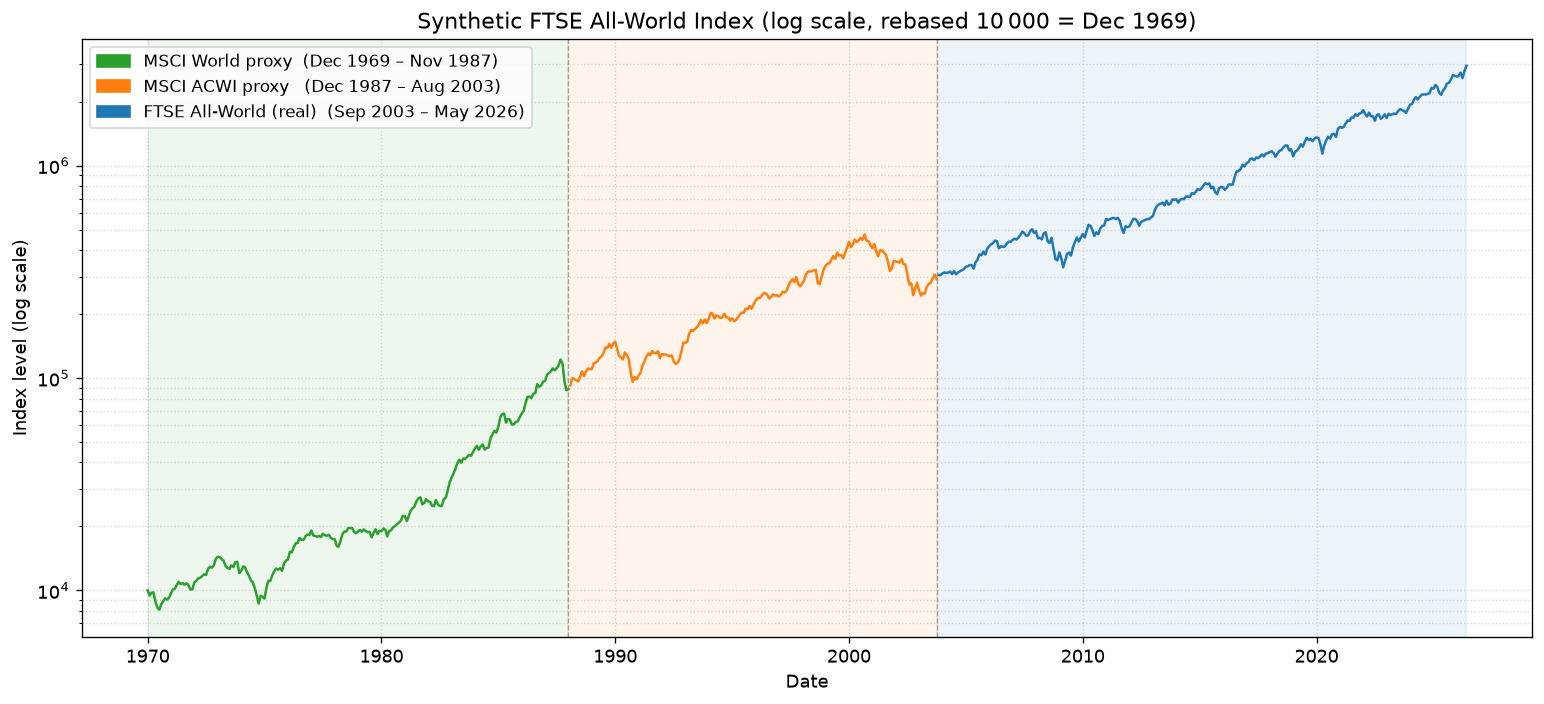

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

# Segment boundaries
seg_c_end = pd.Timestamp("1987-12-31")
seg_b_end = pd.Timestamp("2003-09-30")

seg_c = synthetic[synthetic.index <= seg_c_end]
seg_b = synthetic[(synthetic.index > seg_c_end) & (synthetic.index <= seg_b_end)]
seg_a = synthetic[synthetic.index > seg_b_end]

colors = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c"}

ax.semilogy(seg_c.index, seg_c.values, color=colors["C"], linewidth=1.5)
ax.semilogy(seg_b.index, seg_b.values, color=colors["B"], linewidth=1.5)
ax.semilogy(seg_a.index, seg_a.values, color=colors["A"], linewidth=1.5)

# Shade the background of each segment
ax.axvspan(synthetic.index[0],   seg_c_end,          alpha=0.08, color=colors["C"])
ax.axvspan(seg_c_end,            seg_b_end,           alpha=0.08, color=colors["B"])
ax.axvspan(seg_b_end,            synthetic.index[-1], alpha=0.08, color=colors["A"])

# Vertical splice lines
for dt in [seg_c_end, seg_b_end]:
    ax.axvline(dt, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)

# Legend
patches = [
    mpatches.Patch(color=colors["C"], label="MSCI World proxy  (Dec 1969 \u2013 Nov 1987)"),
    mpatches.Patch(color=colors["B"], label="MSCI ACWI proxy   (Dec 1987 \u2013 Aug 2003)"),
    mpatches.Patch(color=colors["A"], label="FTSE All-World (real)  (Sep 2003 \u2013 May 2026)"),
]
ax.legend(handles=patches, loc="upper left", fontsize=10)

ax.set_title("Synthetic FTSE All-World Index (log scale, rebased 10\u202f000 = Dec 1969)", fontsize=13)
ax.set_ylabel("Index level (log scale)")
ax.set_xlabel("Date")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 6  Sanity checks

In [8]:
# Check 1 – index length matches MSCI World (both start Dec 1969)
assert len(synthetic) == len(world), (
    f"Expected {len(world)} months, got {len(synthetic)}"
)
print(f"\u2713 Length: {len(synthetic)} months")

# Check 2 – rebased to exactly 10 000 at Dec 1969
assert abs(synthetic[base_date] - 10_000) < 1e-6, "Rebase failed"
print(f"\u2713 Base value: {synthetic[base_date]:.6f}")

# Check 3 – strictly positive, no NaNs
assert synthetic.isna().sum() == 0, "NaNs present"
assert (synthetic > 0).all(), "Non-positive values present"
print("\u2713 No NaNs, all values positive")

# Check 4 – in the FTSE era, returns are preserved exactly
r_synth = log_returns(synthetic)
r_ftse_check = log_returns(ftse)
shared_idx = r_synth.index.intersection(r_ftse_check.index)
corr_self, _ = stats.pearsonr(
    r_synth.reindex(shared_idx).dropna(),
    r_ftse_check.reindex(shared_idx).dropna(),
)
max_diff = (r_synth.reindex(shared_idx) - r_ftse_check.reindex(shared_idx)).abs().max()
assert corr_self > 0.9999, f"FTSE returns not preserved! corr = {corr_self}"
assert max_diff < 1e-10, f"Max return diff in FTSE era: {max_diff}"
print(f"\u2713 FTSE era returns preserved: corr = {corr_self:.8f}, max abs diff = {max_diff:.2e}")

print("\nAll sanity checks passed.")

✓ Length: 678 months
✓ Base value: 10000.000000
✓ No NaNs, all values positive
✓ FTSE era returns preserved: corr = 1.00000000, max abs diff = 3.40e-16

All sanity checks passed.


## 7  Export

In [9]:
output_path = "data/synthetic_ftse_all_world.csv"

df_out = synthetic.reset_index()
df_out.columns = ["Date", "Synthetic FTSE All-World"]
df_out["Date"] = df_out["Date"].dt.strftime("%m/%Y")
df_out.to_csv(output_path, index=False)

print(f"Exported {len(df_out)} rows to {output_path}")
print(f"  Start : {df_out['Date'].iloc[0]}   Value: {df_out['Synthetic FTSE All-World'].iloc[0]:,.2f}")
print(f"  End   : {df_out['Date'].iloc[-1]}   Value: {df_out['Synthetic FTSE All-World'].iloc[-1]:,.2f}")

Exported 678 rows to data/synthetic_ftse_all_world.csv
  Start : 12/1969   Value: 10,000.00
  End   : 05/2026   Value: 2,955,640.18


## 8  Quick preview of the output

In [10]:
df_check = pd.read_csv(output_path)
print(f"Rows: {len(df_check)}")
df_check.head(6)

Rows: 678


,Date,Synthetic FTSE All-World
0,12/1969,10000.0
1,01/1970,9445.5
2,02/1970,9740.5
3,03/1970,9770.8
4,04/1970,8857.8
5,05/1970,8299.0


In [11]:
df_check.tail(6)

,Date,Synthetic FTSE All-World
672,12/2025,2.628158e+06
673,01/2026,2.649141e+06
674,02/2026,2.744256e+06
675,03/2026,2.587258e+06
676,04/2026,2.793090e+06
677,05/2026,2.955640e+06
